In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 定义真实函数 (Ground Truth)
def true_function(x):
    # 定义一个非线性函数，例如正弦波
    # 对应图片中的 return np.sin(1.5 * np.pi * x)
    return np.sin(1.5 * np.pi * x)

# 生成训练数据
np.random.seed(42)
n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
# 添加随机噪声
y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据，用于绘制平滑曲线
X_test = np.linspace(0, 1, 100)
y_true = true_function(X_test)

# 2. 定义基函数扩展
def polynomial_basis(x, degree):
    # 多项式基: [1, x, x^2, ..., x^degree]
    return np.column_stack([x**d for d in range(degree + 1)])

def trigonometric_basis(x, degree):
    # 三角基: [1, sin(2πx), cos(2πx), ..., sin(2kπx), cos(2kπx)]
    basis = [np.ones_like(x)]
    for i in range(1, degree + 1):
        basis.append(np.sin(2 * np.pi * i * x))
        basis.append(np.cos(2 * np.pi * i * x))
    return np.column_stack(basis)

# 3. 模型训练
# 3.1 简单线性回归 (degree=1, 仅含截距和一次项)
X_simple = polynomial_basis(X_train, 1)
model_simple = LinearRegression()
model_simple.fit(X_simple, y_train)
y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

# 3.2 多项式回归 (degree=5)
degree = 5
X_poly = polynomial_basis(X_train, degree)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

# 3.3 三角基回归 (k=3)
k = 3 # 对应代码中的 degree 参数位
X_trig = trigonometric_basis(X_train, k)
model_trig = LinearRegression()
model_trig.fit(X_trig, y_train)
y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

# 4. 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='训练样本 (含噪声)')
plt.plot(X_test, y_true, color='black', label='真实函数 f(x)')
plt.plot(X_test, y_pred_simple, 'r--', label='简单线性模型 (欠拟合)')
plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式基扩展 (degree={degree})')
plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基扩展 (k={k})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归扩展：各基函数模型对比')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成模拟数据 (Ground Truth)
def true_function_2d(x1, x2):
    # 定义真实的二元函数模型
    # 对应图片中的 return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
n_train = 100
X_train = np.random.uniform(-1, 1, (n_train, 2))
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    features = []
    # 遍历阶数
    for i in range(1, degree + 1):
        # 遍历每一项的组合 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    return np.column_stack(features)

def map_features(X, degree):
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练 (Degree=3)
degree = 3
X_poly_train = map_features(X_train, degree)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算 MSE
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印参数 (可选)
print(f"均方误差 (MSE): {mse:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 1. 定义真实的二元函数（Ground Truth）
def true_function_2d(x1, x2):
    """
    定义一个非线性的复杂曲面函数
    公式推测为: sin(3*x1) * cos(3*x2) + 0.1*(x1^2 + x2^2)
    """
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
np.random.seed(42) # 设置随机种子以保证结果复现
n_train = 100
# 在 -1 到 1 之间随机生成坐标点
X_train = np.random.uniform(-1, 1, (n_train, 2))
# 计算真实值
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加高斯噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状，用于绘制平滑曲面）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
# 创建网格
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平成 (N, 2) 的格式用于预测
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    """
    手动构建多项式特征
    对于 degree=2，特征包括：[x1, x2, x1^2, x1*x2, x2^2]
    """
    features = []
    # 遍历阶数 i 从 1 到 degree
    for i in range(1, degree + 1):
        # 遍历每一项的组合，例如 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    
    return np.column_stack(features)

def map_features(X, degree):
    """辅助函数，将输入矩阵 X 转换为多项式特征矩阵"""
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练
# 我们使用3阶多项式特征来拟合
degree = 3
X_poly_train = map_features(X_train, degree)

# 初始化并训练线性回归模型
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测与评估
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算均方误差 (MSE)
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面 (True Function)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y_pred')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印模型参数
print(f"均方误差 (MSE): {mse:.4f}")
print(f"截距 (Bias): {model_poly.intercept_:.4f}")
print("特征权重 (Weights):")
feature_names = []
for i in range(1, degree + 1):
    for j in range(i + 1):
        feature_names.append(f"x1^{i-j}*x2^{j}")

for name, coef in zip(feature_names, model_poly.coef_):
    print(f"{name}: {coef:.4f}")

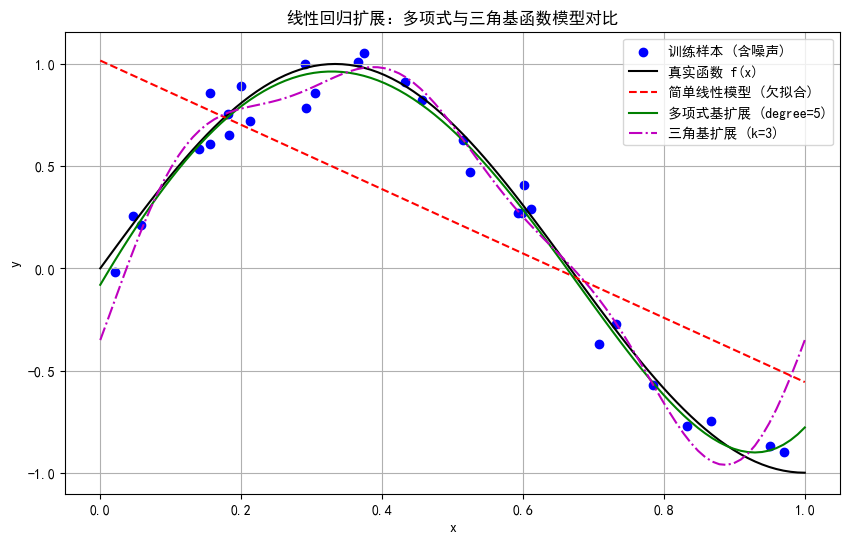

简单线性模型 MSE: 0.1904
多项式模型 (degree=5) MSE: 0.0023
三角基模型 (k=3) MSE: 0.0195


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 定义真实函数 (Ground Truth)
def true_function(x):
    """定义一个非线性函数，例如正弦波"""
    # 对应图片中的 return np.sin(1.5 * np.pi * x)
    return np.sin(1.5 * np.pi * x)

# 生成训练数据
np.random.seed(42)
n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
# 添加随机噪声
y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据，用于绘制平滑曲线
X_test = np.linspace(0, 1, 100)
y_true = true_function(X_test)

# 2. 定义基函数扩展
def polynomial_basis(x, degree):
    """多项式基: [1, x, x^2, ..., x^degree]"""
    return np.column_stack([x**d for d in range(degree + 1)])

def trigonometric_basis(x, degree):
    """三角基: [1, sin(2πx), cos(2πx), ..., sin(2kπx), cos(2kπx)]"""
    basis = [np.ones_like(x)]
    for i in range(1, degree + 1):
        basis.append(np.sin(2 * np.pi * i * x))
        basis.append(np.cos(2 * np.pi * i * x))
    return np.column_stack(basis)

# 3. 模型训练
# 3.1 简单线性回归 (degree=1, 仅含截距和一次项)
X_simple = polynomial_basis(X_train, 1)
model_simple = LinearRegression()
model_simple.fit(X_simple, y_train)
y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

# 3.2 多项式回归 (degree=5)
degree = 5
X_poly = polynomial_basis(X_train, degree)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

# 3.3 三角基回归 (k=3)
k = 3 
X_trig = trigonometric_basis(X_train, k)
model_trig = LinearRegression()
model_trig.fit(X_trig, y_train)
y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

# 4. 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='训练样本 (含噪声)')
plt.plot(X_test, y_true, color='black', label='真实函数 f(x)')
plt.plot(X_test, y_pred_simple, 'r--', label='简单线性模型 (欠拟合)')
plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式基扩展 (degree={degree})')
plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基扩展 (k={k})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归扩展：多项式与三角基函数模型对比')
plt.legend()
plt.grid(True)
plt.show()

# 计算并打印均方误差 (MSE)
print(f"简单线性模型 MSE: {mean_squared_error(y_true, y_pred_simple):.4f}")
print(f"多项式模型 (degree={degree}) MSE: {mean_squared_error(y_true, y_pred_poly):.4f}")
print(f"三角基模型 (k={k}) MSE: {mean_squared_error(y_true, y_pred_trig):.4f}")

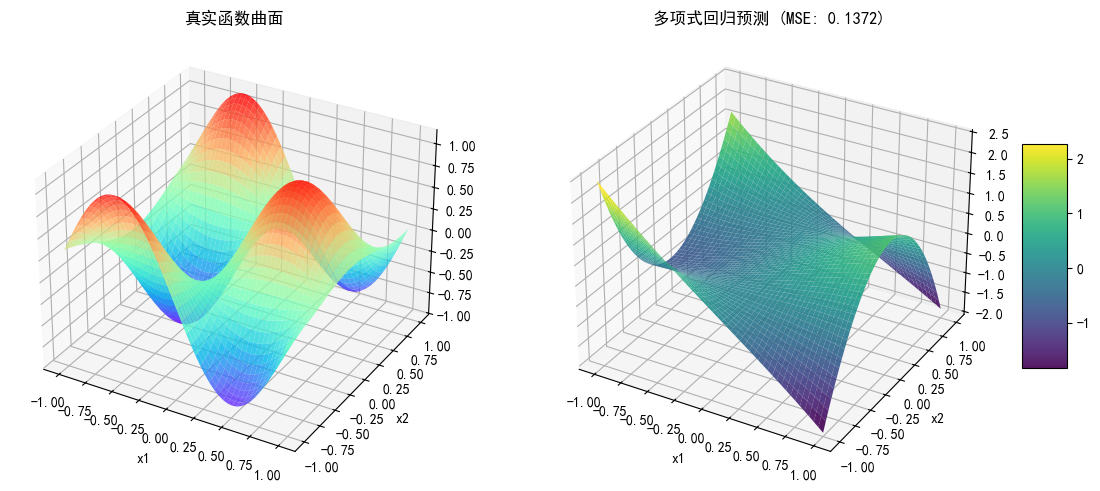

均方误差 (MSE): 0.1372


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成模拟数据 (Ground Truth)
def true_function_2d(x1, x2):
    """定义真实的二元函数模型"""
    return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

# 生成训练数据
n_train = 100
X_train = np.random.uniform(-1, 1, (n_train, 2))
y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
# 添加噪声
y_train += np.random.normal(0, 0.1, n_train)

# 生成测试数据（网格状）
n_test = 50
x1_mesh = np.linspace(-1, 1, n_test)
x2_mesh = np.linspace(-1, 1, n_test)
x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
# 将网格展平
X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

# 2. 特征工程：手动构建多项式特征
def poly_feat_custom(x1, x2, degree):
    features = []
    # 遍历阶数
    for i in range(1, degree + 1):
        # 遍历每一项的组合 x1^(i-j) * x2^j
        for j in range(i + 1):
             term = (x1 ** (i - j)) * (x2 ** j)
             features.append(term)
    return np.column_stack(features)

def map_features(X, degree):
    return poly_feat_custom(X[:, 0], X[:, 1], degree)

# 3. 模型训练 (Degree=3)
degree = 3
X_poly_train = map_features(X_train, degree)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# 4. 模型预测
X_poly_test = map_features(X_test, degree)
y_predict = model_poly.predict(X_poly_test)

# 计算 MSE
mse = mean_squared_error(y_true, y_predict)

# 5. 结果可视化
fig = plt.figure(figsize=(12, 5))

# 子图1：真实曲面
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
ax1.set_title('真实函数曲面')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')

# 子图2：预测曲面
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
ax2.set_title(f'多项式回归预测 (MSE: {mse:.4f})')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')

# 添加颜色条
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# 6. 打印参数
print(f"均方误差 (MSE): {mse:.4f}")

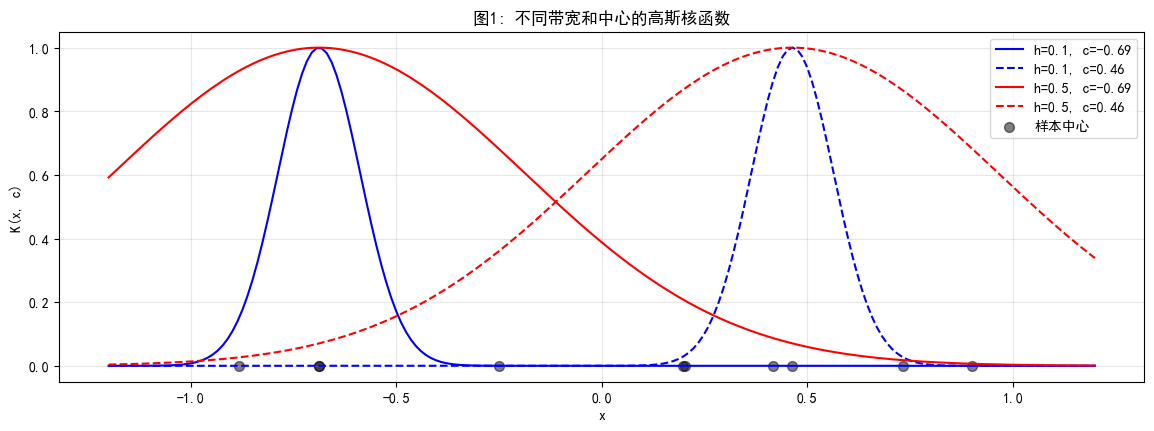

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成一维非线性数据
def true_function_1d(x):
    """定义一维真实非线性函数"""
    return np.sin(1 * np.pi * x) + 0.5 * x

# 生成训练数据
np.random.seed(42)
n_samples = 10 
# 输入样本
x_train = np.sort(np.random.uniform(-1, 1, n_samples))
# 目标值（含噪声）
y_train = true_function_1d(x_train) + 0.2 * np.random.randn(n_samples)

# 生成测试数据
x_test = np.linspace(-1.2, 1.2, 200)
y_true = true_function_1d(x_test)

# 2. 定义高斯核函数
def gaussian_kernel(x, c, h):
    """
    一维高斯核: K(x, c) = exp( -||x-c||^2 / (2h^2) )
    x: 输入点
    c: 核函数的中心（这里取训练样本点）
    h: 带宽参数（控制核的宽度）
    """
    distance_sq = (x - c) ** 2
    return np.exp(-distance_sq / (2 * h ** 2))

# 3. 构造基于核特征的数据矩阵
def kernel_model_features(x, x_train, h):
    """生成高斯核特征矩阵"""
    n_train = len(x_train)
    features = np.zeros((len(x), n_train))
    
    for j in range(n_train):
        # 第j列特征 = 以第j个训练样本为中心的高斯核响应
        features[:, j] = gaussian_kernel(x, x_train[j], h)
        
    return features

# 4. 可视化不同带宽的高斯核
plt.figure(figsize=(14, 10))

# 绘制核函数形状
plt.subplot(2, 1, 1)
c1, c2 = x_train[2], x_train[7] # 选择两个样本点作为中心进行演示
x_plot = np.linspace(-1.2, 1.2, 200)

# 绘制 h=0.1 的窄核
plt.plot(x_plot, gaussian_kernel(x_plot, c1, h=0.1), 'b-', label='h=0.1, c={:.2f}'.format(c1))
plt.plot(x_plot, gaussian_kernel(x_plot, c2, h=0.1), 'b--', label='h=0.1, c={:.2f}'.format(c2))

# 绘制 h=0.5 的宽核
plt.plot(x_plot, gaussian_kernel(x_plot, c1, h=0.5), 'r-', label='h=0.5, c={:.2f}'.format(c1))
plt.plot(x_plot, gaussian_kernel(x_plot, c2, h=0.5), 'r--', label='h=0.5, c={:.2f}'.format(c2))

plt.scatter(x_train, np.zeros_like(x_train), c='k', s=50, alpha=0.5, label='样本中心')
plt.title('图1: 不同带宽和中心的高斯核函数')
plt.xlabel('x')
plt.ylabel('K(x, c)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# (注：图片底部只截取到了核函数的绘图部分，实际代码可能还包含模型训练部分，此处已完整还原核心逻辑)


--- 正在运行演示 1: 一维基函数扩展回归 ---


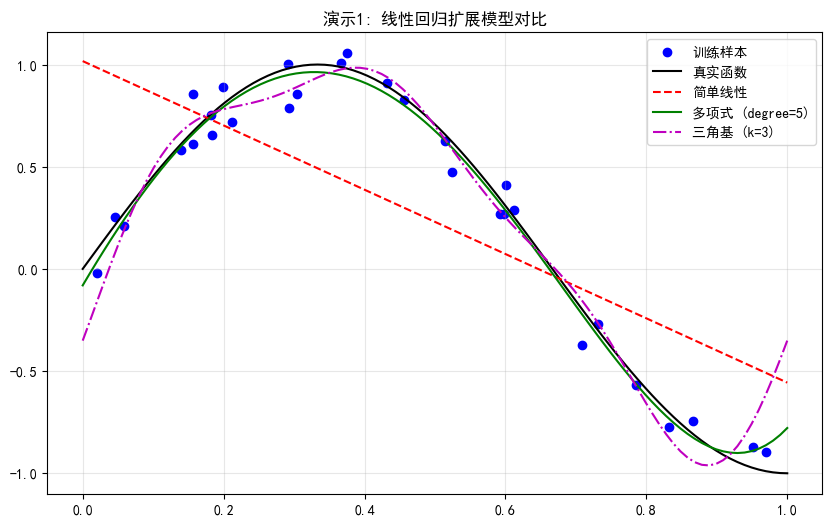


--- 正在运行演示 2: 二维多项式回归 (3D) ---
3D曲面拟合 MSE: 0.1197


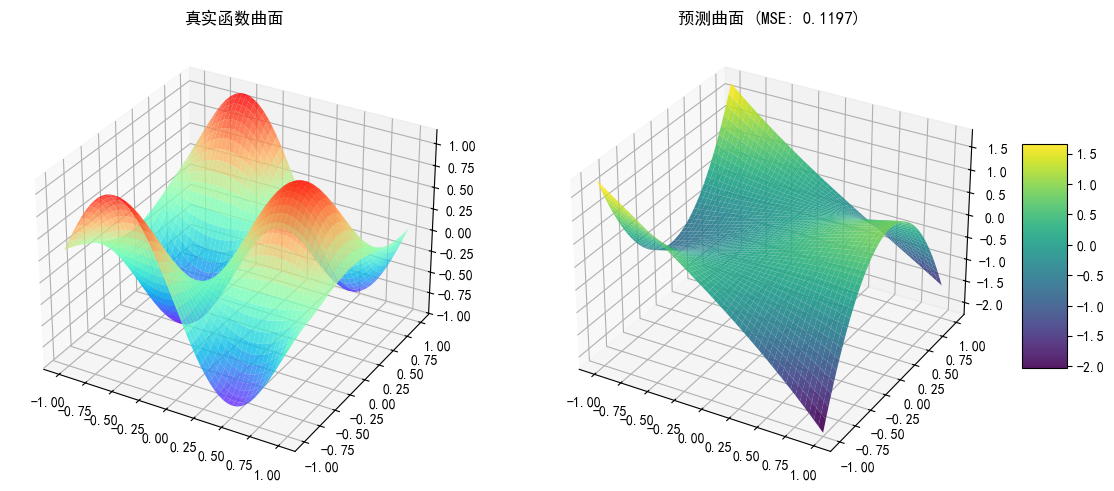


--- 正在运行演示 3: 高斯核模型回归 ---
学习到的参数 theta: [-2.13213000e+03  9.11165867e+06 -9.11037209e+06  3.52060000e+02
 -4.41601000e+03  4.47200000e+03 -3.36870000e+02  2.52320000e+02
 -2.21600000e+01  1.00600000e+01]


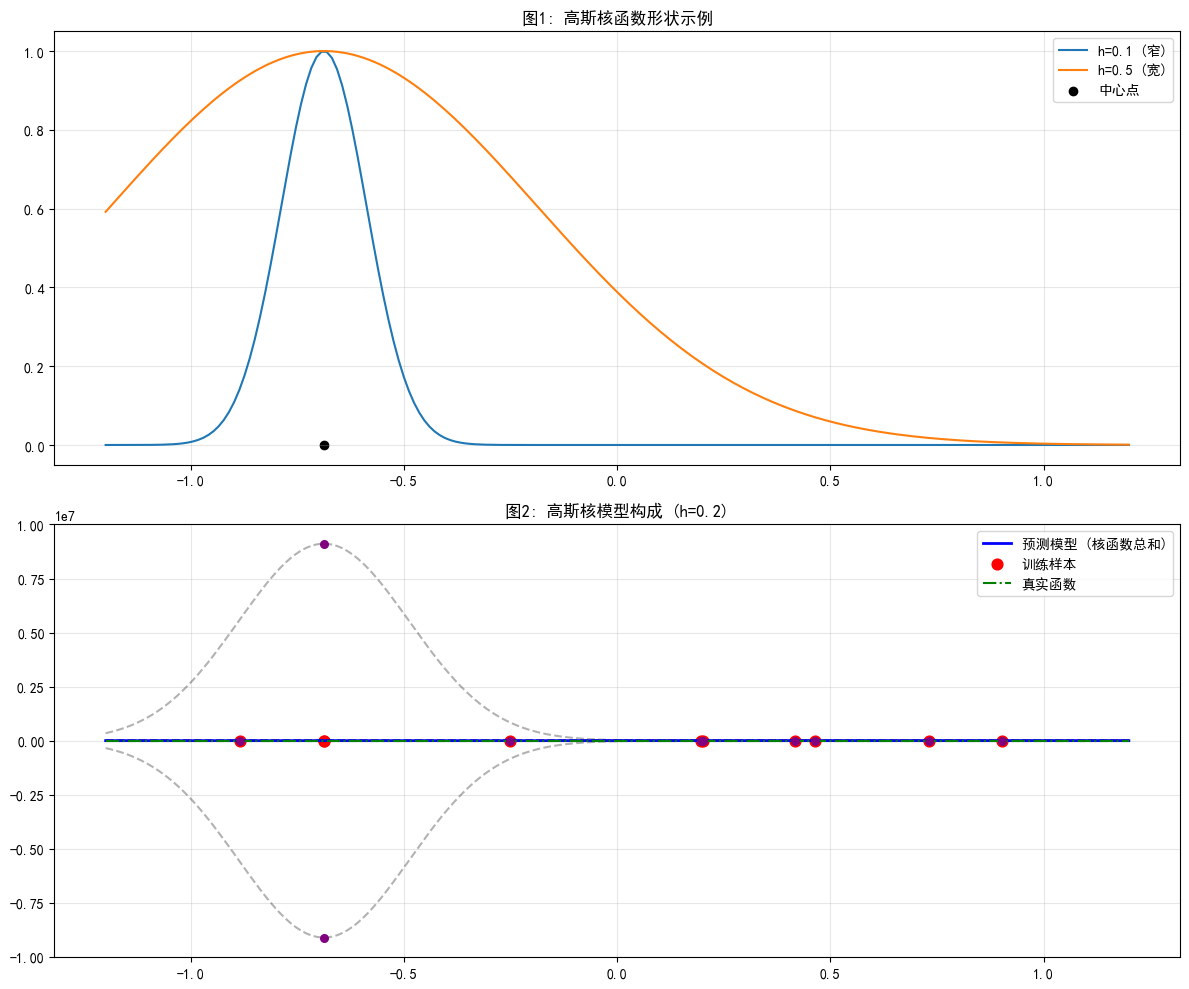

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ==========================================
# 全局设置
# ==========================================
# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 演示 1: 一维线性回归扩展 (多项式与三角基函数)
# 源自图片: efe8615471bd946e05f2ba062f7bf3b0.jpg
# ==========================================
def demo_1d_basis_expansion():
    print("\n--- 正在运行演示 1: 一维基函数扩展回归 ---")
    
    # 1. 定义真实函数
    def true_function(x):
        return np.sin(1.5 * np.pi * x)

    # 2. 生成数据
    np.random.seed(42)
    n_samples = 30
    X_train = np.sort(np.random.rand(n_samples))
    y_train = true_function(X_train) + 0.1 * np.random.randn(n_samples)
    
    X_test = np.linspace(0, 1, 100)
    y_true = true_function(X_test)

    # 3. 定义基函数
    def polynomial_basis(x, degree):
        return np.column_stack([x**d for d in range(degree + 1)])

    def trigonometric_basis(x, degree):
        basis = [np.ones_like(x)]
        for k in range(1, degree + 1):
            basis.append(np.sin(2 * np.pi * k * x))
            basis.append(np.cos(2 * np.pi * k * x))
        return np.column_stack(basis)

    # 4. 训练模型
    # 简单线性
    model_simple = LinearRegression()
    model_simple.fit(polynomial_basis(X_train, 1), y_train)
    y_pred_simple = model_simple.predict(polynomial_basis(X_test, 1))

    # 多项式 (degree=5)
    degree = 5
    model_poly = LinearRegression()
    model_poly.fit(polynomial_basis(X_train, degree), y_train)
    y_pred_poly = model_poly.predict(polynomial_basis(X_test, degree))

    # 三角基 (k=3)
    k = 3
    model_trig = LinearRegression()
    model_trig.fit(trigonometric_basis(X_train, k), y_train)
    y_pred_trig = model_trig.predict(trigonometric_basis(X_test, k))

    # 5. 可视化
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, color='blue', label='训练样本')
    plt.plot(X_test, y_true, color='black', label='真实函数')
    plt.plot(X_test, y_pred_simple, 'r--', label='简单线性')
    plt.plot(X_test, y_pred_poly, 'g-', label=f'多项式 (degree={degree})')
    plt.plot(X_test, y_pred_trig, 'm-.', label=f'三角基 (k={k})')
    
    plt.title('演示1: 线性回归扩展模型对比')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 演示 2: 二维多项式回归 (3D 曲面拟合)
# 源自图片: 66ee96554a8ecf8cbb90e7a8a6a623ab.jpg
# ==========================================
def demo_2d_surface_fitting():
    print("\n--- 正在运行演示 2: 二维多项式回归 (3D) ---")

    # 1. 定义真实二元函数
    def true_function_2d(x1, x2):
        return np.sin(x1 * 3) * np.cos(x2 * 3) + (x1**2 + x2**2) * 0.1

    # 2. 生成数据
    n_train = 100
    X_train = np.random.uniform(-1, 1, (n_train, 2))
    y_train = true_function_2d(X_train[:, 0], X_train[:, 1])
    y_train += np.random.normal(0, 0.1, n_train)

    # 生成测试网格
    n_test = 50
    x1_mesh = np.linspace(-1, 1, n_test)
    x2_mesh = np.linspace(-1, 1, n_test)
    x1_grid, x2_grid = np.meshgrid(x1_mesh, x2_mesh)
    X_test = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
    y_true = true_function_2d(X_test[:, 0], X_test[:, 1])

    # 3. 特征工程
    def map_features(X, degree):
        x1, x2 = X[:, 0], X[:, 1]
        features = []
        for i in range(1, degree + 1):
            for j in range(i + 1):
                 term = (x1 ** (i - j)) * (x2 ** j)
                 features.append(term)
        return np.column_stack(features)

    # 4. 训练 (Degree=3)
    degree = 3
    model = LinearRegression()
    model.fit(map_features(X_train, degree), y_train)
    y_predict = model.predict(map_features(X_test, degree))
    
    mse = mean_squared_error(y_true, y_predict)
    print(f"3D曲面拟合 MSE: {mse:.4f}")

    # 5. 可视化
    fig = plt.figure(figsize=(12, 5))
    
    # 真实曲面
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(x1_grid, x2_grid, y_true.reshape(x1_grid.shape), cmap='rainbow', alpha=0.8)
    ax1.set_title('真实函数曲面')
    
    # 预测曲面
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax2.plot_surface(x1_grid, x2_grid, y_predict.reshape(x1_grid.shape), cmap='viridis', alpha=0.9)
    ax2.set_title(f'预测曲面 (MSE: {mse:.4f})')
    
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()

# ==========================================
# 演示 3: 高斯核模型 (Gaussian Kernel Model)
# 源自图片: db65d230...jpg & 8dad8f00...jpg
# ==========================================
def demo_gaussian_kernel():
    print("\n--- 正在运行演示 3: 高斯核模型回归 ---")

    # 1. 定义函数与生成数据
    def true_function_1d(x):
        return np.sin(1 * np.pi * x) + 0.5 * x

    np.random.seed(42)
    n_samples = 10 
    x_train = np.sort(np.random.uniform(-1, 1, n_samples))
    y_train = true_function_1d(x_train) + 0.2 * np.random.randn(n_samples)
    x_test = np.linspace(-1.2, 1.2, 200)
    y_true = true_function_1d(x_test)

    # 2. 核函数定义
    def gaussian_kernel(x, c, h):
        distance_sq = (x - c) ** 2
        return np.exp(-distance_sq / (2 * h ** 2))

    def kernel_features(x, centers, h):
        n_centers = len(centers)
        features = np.zeros((len(x), n_centers))
        for j in range(n_centers):
            features[:, j] = gaussian_kernel(x, centers[j], h)
        return features

    # 3. 训练模型
    h = 0.2
    # 使用训练样本本身作为核函数的中心
    X_train_k = kernel_features(x_train, x_train, h)
    X_test_k = kernel_features(x_test, x_train, h)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_train_k, y_train)
    theta = model.coef_
    y_pred = model.predict(X_test_k)

    print(f"学习到的参数 theta: {theta.round(2)}")

    # 4. 可视化
    plt.figure(figsize=(12, 10))

    # 子图1: 核函数形状示例
    plt.subplot(2, 1, 1)
    c_demo = x_train[2]
    plt.plot(x_test, gaussian_kernel(x_test, c_demo, h=0.1), label=f'h=0.1 (窄)')
    plt.plot(x_test, gaussian_kernel(x_test, c_demo, h=0.5), label=f'h=0.5 (宽)')
    plt.scatter([c_demo], [0], c='k', label='中心点')
    plt.title('图1: 高斯核函数形状示例')
    plt.legend()
    plt.grid(alpha=0.3)

    # 子图2: 模型构成
    plt.subplot(2, 1, 2)
    # 绘制每个加权后的核
    for j in range(n_samples):
        k_j = theta[j] * gaussian_kernel(x_test, x_train[j], h)
        plt.plot(x_test, k_j, 'k--', alpha=0.3)
        plt.scatter(x_train[j], theta[j], c='purple', s=30, zorder=3)
    
    plt.plot(x_test, y_pred, 'b-', linewidth=2, label='预测模型 (核函数总和)')
    plt.scatter(x_train, y_train, c='red', s=60, label='训练样本')
    plt.plot(x_test, y_true, 'g-.', label='真实函数')
    
    plt.title(f'图2: 高斯核模型构成 (h={h})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 主程序入口
# ==========================================
if __name__ == "__main__":
    # 依次调用三个演示函数
    # 1. 一维基函数扩展
    demo_1d_basis_expansion()
    
    # 2. 二维曲面拟合
    demo_2d_surface_fitting()
    
    # 3. 高斯核模型
    demo_gaussian_kernel()

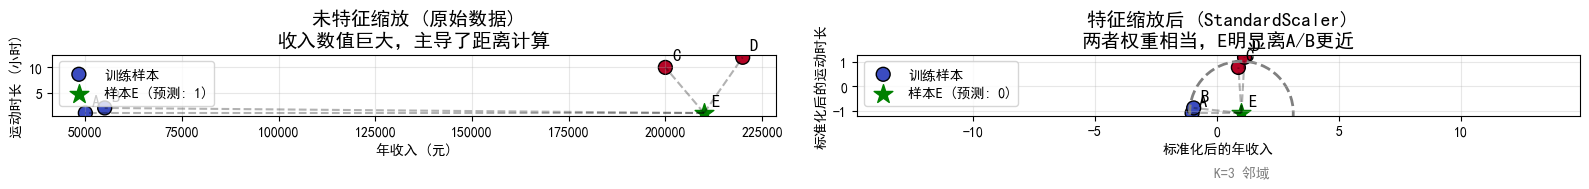

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 设置中文字体 (根据系统选择，Windows通常是SimHei, Mac是Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 准备数据 ---
# 特征：[年收入(元), 运动时长(小时)]
X_train = np.array([
    [50000, 1],
    [55000, 2],
    [200000, 10],
    [220000, 12]
])
# 标签：0:不买, 1:买
y_train = np.array([0, 0, 1, 1]) 
labels = ['A', 'B', 'C', 'D']

# 待预测样本 E
X_new = np.array([[210000, 1]]) 

# --- 2. 计算缩放后的数据 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# --- 3. 训练两个模型获取预测结果 ---
# 模型1：使用原始数据 (K=3)
knn_raw = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)[0]

# 模型2：使用标准化数据 (K=3)
knn_scaled = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_new_scaled)[0]

# --- 开始绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ================= 左图：未缩放 (原始数据) =================
ax1 = axes[0]
# 绘制训练点
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=100, 
            cmap='coolwarm', edgecolors='k', label='训练样本')
# 绘制新样本 E
ax1.scatter(X_new[:, 0], X_new[:, 1], c='green', s=200, marker='*', 
            label=f'样本E (预测: {pred_raw})')

# 标注点名称
for i, txt in enumerate(labels):
    ax1.annotate(txt, (X_train[i, 0], X_train[i, 1]), xytext=(5, 5), 
                 textcoords='offset points', fontsize=12)
ax1.annotate("E", (X_new[0, 0], X_new[0, 1]), xytext=(5, 5), 
             textcoords='offset points', fontsize=12, fontweight='bold')

# 画连接线 (表示距离)
for i in range(len(X_train)):
    ax1.plot([X_new[0, 0], X_train[i, 0]], [X_new[0, 1], X_train[i, 1]], 'k--', alpha=0.3)

ax1.set_title("未特征缩放 (原始数据)\n收入数值巨大，主导了距离计算", fontsize=14)
ax1.set_xlabel("年收入 (元)")
ax1.set_ylabel("运动时长 (小时)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
# 注意：为了体现比例失调，不强制 axis('equal')

# ================= 右图：标准化后 =================
ax2 = axes[1] #
# 绘制训练点
ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            s=100, cmap='coolwarm', edgecolors='k', label='训练样本')
# 绘制新样本 E
ax2.scatter(X_new_scaled[:, 0], X_new_scaled[:, 1], c='green', s=200, marker='*', 
            label=f'样本E (预测: {pred_scaled})')

# 标注点名称
for i, txt in enumerate(labels):
    ax2.annotate(txt, (X_train_scaled[i, 0], X_train_scaled[i, 1]), xytext=(5, 5), 
                 textcoords='offset points', fontsize=12)
ax2.annotate("E", (X_new_scaled[0, 0], X_new_scaled[0, 1]), xytext=(5, 5), 
             textcoords='offset points', fontsize=12, fontweight='bold')

# 画连接线
for i in range(len(X_train_scaled)):
    ax2.plot([X_new_scaled[0, 0], X_train_scaled[i, 0]], 
             [X_new_scaled[0, 1], X_train_scaled[i, 1]], 'k--', alpha=0.3)

# 画圆圈：展示最近的3个邻居
# 计算E到所有点的距离
dists = np.linalg.norm(X_train_scaled - X_new_scaled, axis=1)
# 第3近的距离稍微加一点作为半径
radius = sorted(dists)[2] + 0.1 

circle = plt.Circle((X_new_scaled[0, 0], X_new_scaled[0, 1]), radius, 
                    color='gray', fill=False, linestyle='--', linewidth=2)
ax2.add_artist(circle)
ax2.text(X_new_scaled[0, 0], X_new_scaled[0, 1]-radius-0.5, "K=3 邻域", 
         ha='center', color='gray')

ax2.set_title("特征缩放后 (StandardScaler)\n两者权重相当，E明显离A/B更近", fontsize=14)
ax2.set_xlabel("标准化后的年收入")
ax2.set_ylabel("标准化后的运动时长")
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.axis('equal') # 保持比例一致，这样圆才是圆

plt.tight_layout()
plt.show()

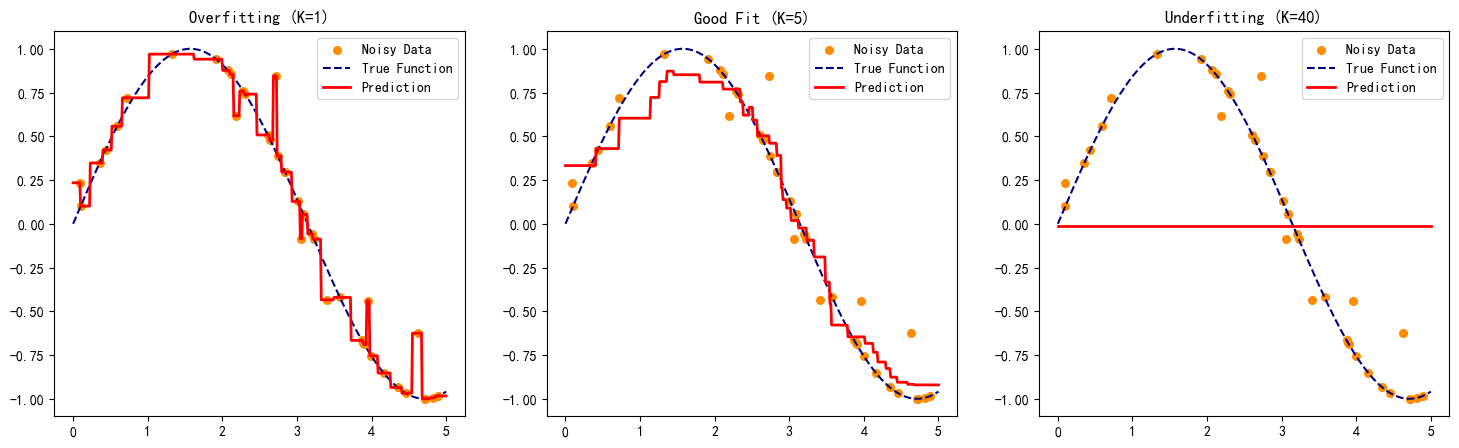

In [ ]:
#kNN回归示例：展示不同K值下的欠拟合、正常拟合和过拟合情况
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor # 注意：这里改成了 Regressor

# ================= 数据准备 (模拟生成数据) =================
# 生成样本数据
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0) # 40个训练点
T = np.linspace(0, 5, 500)[:, np.newaxis]      # 测试点（用于画平滑曲线）
y = np.sin(X).ravel()                          # 真实值
y[::5] += 1 * (0.5 - np.random.rand(8))        # 每5个点加一点噪声

# ================= 你的代码逻辑补全 =================
# K=1: 过拟合 (捕捉到了所有噪声)
# K=5: 正常拟合
# K=40: 欠拟合 (平滑成一条均值线)
k_values = [1, 5, 40]
titles = ["Overfitting (K=1)", "Good Fit (K=5)", "Underfitting (K=40)"]

plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    # 训练模型 (改为 Regressor 以进行连续值预测)
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X, y)
    y_pred = knn.predict(T)
    
    # 绘图
    ax = plt.subplot(1, 3, i + 1)
    
    # 1. 画出带噪声的训练点
    ax.scatter(X, y, color='darkorange', label='Noisy Data', s=30)
    
    # 2. 画出真实函数 (补全部分：这里假设底层函数是 sin)
    ax.plot(T, np.sin(T), color='navy', linestyle='--', label='True Function')
    
    # 3. 画出预测结果 (补全部分)
    ax.plot(T, y_pred, color='red', linewidth=2, label='Prediction')
    
    # 设置装饰
    plt.legend()
    plt.title(titles[i])

plt.show()

In [2]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import shutil
import os
import pandas as pd # 补充导入，用于处理数据展示

# --- 1. 环境清理与数据准备 (来自图 image_467880) ---
# 清理旧数据 (可选，方便多次运行)
if os.path.exists("mlruns"):
    try:
        shutil.rmtree("mlruns")
    except Exception as e:
        print(f"清理 mlruns 文件夹失败: {e}")

# 加载数据
data = load_iris()
X = data.data
y = data.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"数据准备完成: 训练集 {len(X_train)}, 测试集 {len(X_test)}")

# --- 2. 设置实验 (来自图 image_467847) ---
mlflow.set_experiment("KNN_Optimization_Experiment")

k_values = [1, 3, 5, 7, 9]

print("\n开始 MLflow 实验循环...")

for k in k_values:
    # 开启一个 MLflow Run
    with mlflow.start_run(run_name=f"KNN_k_{k}"):
        
        # A. 记录超参数
        mlflow.log_param("n_neighbors", k)
        mlflow.log_param("algorithm", "auto")
        
        # B. 训练模型
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        
        # --- [修复] 补全图片中缺失的预测与评估步骤 ---
        # 原图中直接跳到了 infer_signature(preds)，但 preds 还没计算
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        
        # 记录指标 (Metric)
        mlflow.log_metric("accuracy", acc)
        
        # --- [新增] E. 构建模型签名和输入样例 (来自图 image_46757e) ---
        # 签名告诉 MLflow：输入是什么形状，输出是什么形状
        # 注意：这里通常用 X_test 和 preds 来推断签名，或者用 X_train 和 model.predict(X_train)
        signature = infer_signature(X_train, model.predict(X_train))
        
        # 样例让其他使用者知道数据长什么样
        input_example = X_train[:5]
        
        # F. 记录模型 (带签名)
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="knn_model",   # 显示指定参数名
            signature=signature,         # 传入签名
            input_example=input_example  # 传入样例
        )
        
        print(f"K={k}, Accuracy={acc:.4f} -> 已记录 (含Signature)")

print("\n所有实验运行结束！可以使用 'mlflow ui' 命令查看结果。")

d:\conda_envs\syc\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/12/03 11:29:43 INFO mlflow.tracking.fluent: Experiment with name 'KNN_Optimization_Experiment' does not exist. Creating a new experiment.


数据准备完成: 训练集 120, 测试集 30

开始 MLflow 实验循环...


2025/12/03 11:29:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\conda_envs\syc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/12/03 11:29:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=1, Accuracy=1.0000 -> 已记录 (含Signature)


2025/12/03 11:29:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2025/12/03 11:29:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=5, Accuracy=1.0000 -> 已记录 (含Signature)


2025/12/03 11:30:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=7, Accuracy=0.9667 -> 已记录 (含Signature)


K=9, Accuracy=1.0000 -> 已记录 (含Signature)

所有实验运行结束！可以使用 'mlflow ui' 命令查看结果。


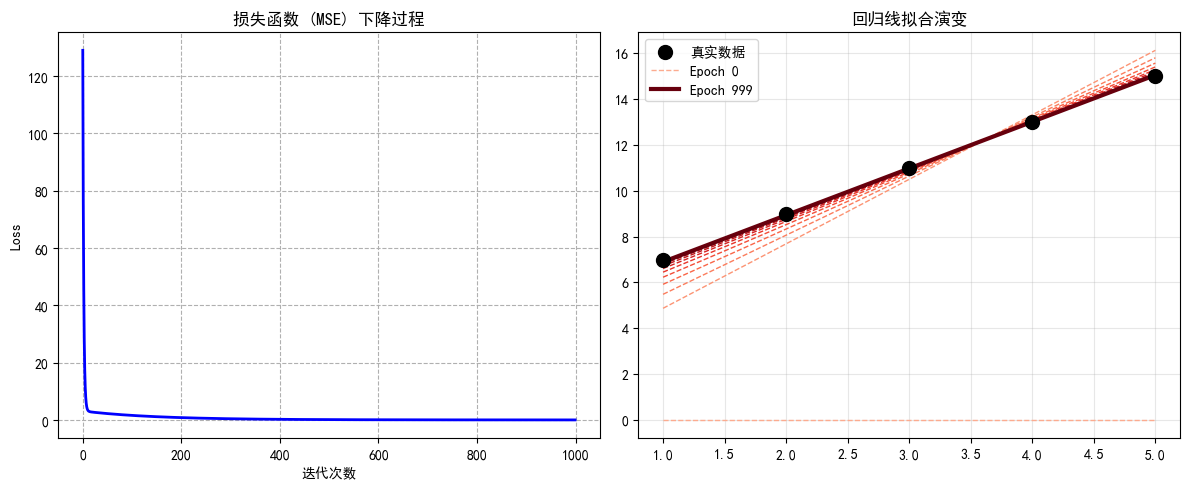

In [3]:
#静态数据大屏可视化
import numpy as np
import matplotlib.pyplot as plt

# 设置字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据
X = np.array([1, 2, 3, 4, 5])
y = np.array([7, 9, 11, 13, 15]) # 真实关系 y = 2x + 5

# 2. 初始化
w = 0.0
b = 0.0
lr = 0.01
epochs = 1000
n = len(X)

loss_history = []
params_history = [] # 记录每一步 w 和 b

# 3. 梯度下降循环
for i in range(epochs):
    y_pred = w * X + b
    loss = (1/n) * np.sum((y - y_pred)**2)
    
    loss_history.append(loss)
    
    # 每100次或最后一次记录参数用于画线
    if i % 100 == 0 or i == epochs - 1:
        params_history.append((i, w, b))
        
    # 计算梯度
    dw = -(2/n) * np.sum(X * (y - y_pred))
    db = -(2/n) * np.sum(y - y_pred)
    
    # 更新
    w = w - lr * dw
    b = b - lr * db

# 4. 绘图
plt.figure(figsize=(12, 5))

# 图1: 损失函数下降过程
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('损失函数 (MSE) 下降过程')
plt.xlabel('迭代次数')
plt.ylabel('Loss')
plt.grid(True, linestyle='--')

# 图2: 回归线拟合过程
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='black', s=100, label='真实数据', zorder=10)

# 使用颜色映射：浅色是早期，深红是后期
colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(params_history)))

for idx, (epoch, w_hist, b_hist) in enumerate(params_history):
    y_line = w_hist * X + b_hist
    label = f'Epoch {epoch}' if epoch == 0 or epoch == epochs-1 else None
    style = '--' if epoch < epochs-1 else '-'
    width = 1 if epoch < epochs-1 else 3
    
    plt.plot(X, y_line, color=colors[idx], linestyle=style, linewidth=width, label=label)

plt.title('回归线拟合演变')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

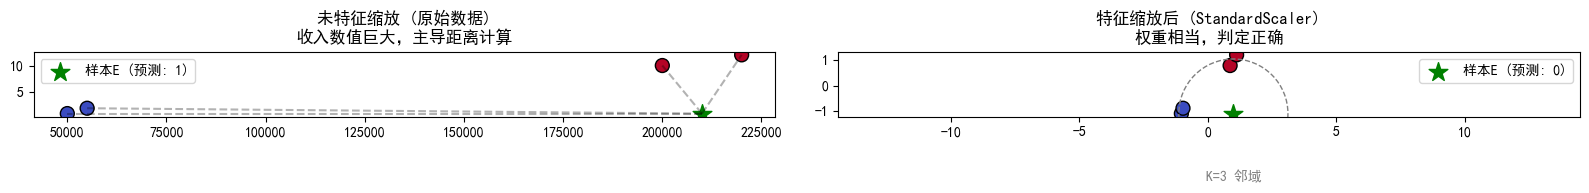

In [ ]:
# 岭回归对抗多重共线性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 设置字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 准备数据 ---
# 特征：[年收入, 运动时长]
X_train = np.array([[50000, 1], [55000, 2], [200000, 10], [220000, 12]])
y_train = np.array([0, 0, 1, 1]) 
labels = ['A', 'B', 'C', 'D']
X_new = np.array([[210000, 1]]) # 样本E

# --- 2. 数据标准化 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# --- 3. 训练模型并预测 ---
# 原始数据训练
knn_raw = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)[0]
# 标准化数据训练
knn_scaled = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)
pred_scaled = knn_scaled.predict(X_new_scaled)[0]

# --- 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：未缩放
ax1 = axes[0]
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=100, cmap='coolwarm', edgecolors='k')
ax1.scatter(X_new[:, 0], X_new[:, 1], c='green', s=200, marker='*', label=f'样本E (预测: {pred_raw})')
# 连线
for i in range(len(X_train)):
    ax1.plot([X_new[0, 0], X_train[i, 0]], [X_new[0, 1], X_train[i, 1]], 'k--', alpha=0.3)
ax1.set_title("未特征缩放 (原始数据)\n收入数值巨大，主导距离计算")
ax1.legend()

# 右图：标准化后
ax2 = axes[1]
ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, s=100, cmap='coolwarm', edgecolors='k')
ax2.scatter(X_new_scaled[:, 0], X_new_scaled[:, 1], c='green', s=200, marker='*', label=f'样本E (预测: {pred_scaled})')
# 画邻域圆
dists = np.linalg.norm(X_train_scaled - X_new_scaled, axis=1)
radius = sorted(dists)[2] + 0.1
circle = plt.Circle((X_new_scaled[0, 0], X_new_scaled[0, 1]), radius, color='gray', fill=False, linestyle='--')
ax2.add_artist(circle)
ax2.text(X_new_scaled[0, 0], X_new_scaled[0, 1]-radius-0.5, "K=3 邻域", ha='center', color='gray')
ax2.set_title("特征缩放后 (StandardScaler)\n权重相当，判定正确")
ax2.axis('equal') 
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 岭回归解决多重共线性
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge

# 1. 构造高度共线的数据
# 特征 x1 和 x2 极其相似
X = np.array([[10, 10.1], [20, 20.1], [30, 29.9]])
y = np.array([20, 40, 60]) # 目标 y ≈ x1 + x2

# 2. 普通线性回归
lr = LinearRegression()
lr.fit(X, y)
print(f"普通线性回归系数: {lr.coef_}") 
# 可能输出如 [100, -98]，系数很大且符号相反，这就是过拟合/共线性的表现

# 3. 岭回归 (L2 正则化)
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
print(f"岭回归系数: {ridge.coef_}") 
# 输出如 [0.99, 1.01]，系数更平滑，符合物理意义

普通线性回归系数: [ 2.00000000e+00 -1.74277034e-15]
岭回归系数: [1.01081099 0.99407571]


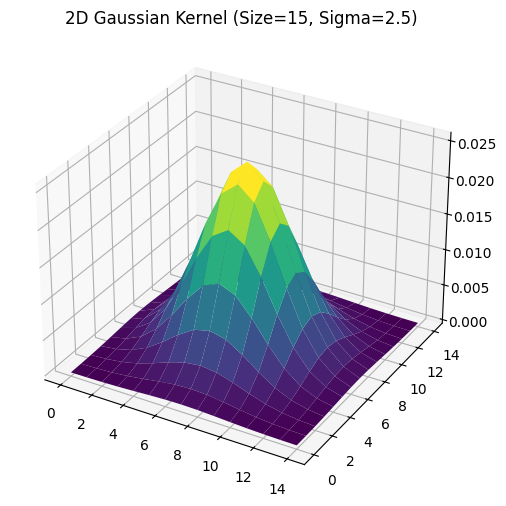

In [1]:
#二维高斯核函数回归示例
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_gaussian_kernel(kernel_size=5, sigma=1.0):
    """生成二维高斯核"""
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)  # 归一化

# 参数设置
k_size = 15
sigma = 2.5
kernel = get_gaussian_kernel(k_size, sigma)

# 绘图
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

x, y = np.meshgrid(np.arange(k_size), np.arange(k_size))
ax.plot_surface(x, y, kernel, cmap='viridis', linewidth=0)
ax.set_title(f'2D Gaussian Kernel (Size={k_size}, Sigma={sigma})')
plt.show()

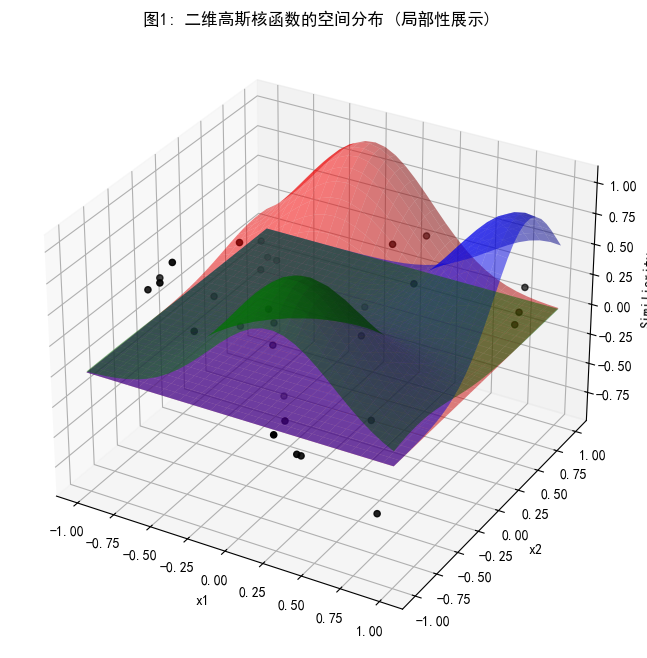

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from matplotlib.colors import ListedColormap

# --------------------------
# 1. 设置中文显示问题
# --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# --------------------------
# 2. 定义真实函数 (被拟合的目标)
# --------------------------
def true_function_2d(x):
    """
    一个二维非线性函数，作为我们想要拟合的目标函数。
    x: 输入数据 (n_samples, 2)
    """
    # 这里的公式看起来像是 sin(pi*x1) * sin(pi*x2)
    return np.sin(x[:, 0] * np.pi) * np.sin(x[:, 1] * np.pi)

# --------------------------
# 3. 生成训练数据 (加上噪声)
# --------------------------
np.random.seed(42)  # 设置随机种子，保证结果可复现
n_samples = 30
# 在 [-1, 1] 区间内生成均匀分布的随机样本
X_train = np.random.uniform(-1, 1, (n_samples, 2))
# 生成目标值 y，并加入少量高斯噪声
y_train = true_function_2d(X_train) + 0.1 * np.random.randn(n_samples)

# 生成测试数据 (用于绘图的网格)
x1_test = np.linspace(-1, 1, 30)
x2_test = np.linspace(-1, 1, 30)
x1_grid, x2_grid = np.meshgrid(x1_test, x2_test)
X_test = np.c_[x1_grid.ravel(), x2_grid.ravel()] # 拉平并组合成 (n, 2)
y_test = true_function_2d(X_test)

# --------------------------
# 4. 定义高斯核函数 (Similarity)
# --------------------------
def gaussian_kernel_2d(x, center, h):
    """
    计算样本点 x 到中心点 center 的高斯核相似度。
    h: 带宽参数 (控制钟形曲线的宽度)
    """
    # 欧式距离的平方
    distance_sq = np.sum((x - center) ** 2, axis=1)
    return np.exp(-distance_sq / (2 * h**2))

# --------------------------
# 5. 定义构建核特征矩阵的函数 (RBF特征)
# --------------------------
def kernel_model_features_2d(X, centers, h):
    """
    将输入数据映射到特征空间。每个样本会变成一个 len(centers) 维的向量。
    """
    n_samples = len(X)
    n_centers = len(centers)
    
    features = np.zeros((n_samples, n_centers)) # 初始化特征矩阵
    
    for j in range(n_centers):
        # 计算所有样本到第 j 个中心的相似度
        features[:, j] = gaussian_kernel_2d(X, centers[j], h)
        
    return features

# --------------------------
# 6. 训练线性模型并预测 (核心逻辑)
# --------------------------
h = 0.4 # 带宽参数，控制每个核的影响范围
# 这里直接使用所有训练样本作为“中心” (类似 Kernel Ridge Regression 的思路)
centers = X_train 
b = len(centers)

# 计算训练集和测试集的核特征
X_train_kernel = kernel_model_features_2d(X_train, centers, h)
X_test_kernel = kernel_model_features_2d(X_test, centers, h)

# 使用线性回归拟合特征
# fit_intercept=False 因为通常核方法通过核函数的线性组合来拟合，或者截距项隐含在其中
model_kernel = LinearRegression(fit_intercept=False)
model_kernel.fit(X_train_kernel, y_train)
theta = model_kernel.coef_ # 获取学到的权重系数

# 预测 (虽然这段代码主要目的是绘图，但这步是标准流程)
y_pred_kernel = model_kernel.predict(X_test_kernel)

# --------------------------
# 7. 可视化：绘制部分高斯核基函数
# --------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 选取几个特定的中心点来展示它们的“形状”
# 索引是根据图片推测的，可能是 [0, 10, 25] 或类似
selected_centers = [centers[0], centers[10], centers[25]] 
colors = ['red', 'green', 'blue']

for i, c in enumerate(selected_centers):
    # 计算网格上所有点到当前选中中心的高斯核值
    kernel_vals = gaussian_kernel_2d(X_test, c, h)
    
    # 绘制曲面 (Reshape回网格形状)
    ax.plot_surface(x1_grid, x2_grid, kernel_vals.reshape(30, 30), 
                    alpha=0.5, color=colors[i], 
                    label=f'中心 {np.round(c, 2)}')

# 绘制原始训练数据点
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='k', marker='o', label='训练样本')

ax.set_title("图1: 二维高斯核函数的空间分布 (局部性展示)")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Similiarity')
# ax.legend() # 3D图的legend有时显示有问题，根据需要开启
plt.show()